<a href="https://colab.research.google.com/github/xysu129/deep-learning-ust-2026/blob/main/260414_Progress_Update.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Progress Update
## Transfer Learning for Breast Ultrasound Segmentation
### Xiaoyang Su


## 1. Dataset and Task

**Task:** Pixel-level segmentation of breast tumors in ultrasound images

**Target dataset:** BUSI (Breast Ultrasound Images)
- 647 images (benign + malignant), split 70/15/15
- Input: 128×128 RGB | Output: 128×128 binary mask (1=tumor, 0=background)
- Labels: pixel-level masks annotated by radiologists

**Pretrain dataset:** ISIC 2019 (Skin Lesion Classification)
- 25,000+ images across 8 diagnostic classes
- Used for pretraining VGG16 encoder (classification task)

**Total input: 8,634 datapoints across all experiments**

**Model:** U-Net (CNN encoder-decoder with skip connections)
- Encoder: VGG16 (5 conv blocks)
- Decoder: transposed convolutions + skip connections
- Loss: BCE + Dice Loss | Metrics: Dice coefficient, IoU


100%|██████████| 195M/195M [00:05<00:00, 39.8MB/s]


Extracting files...


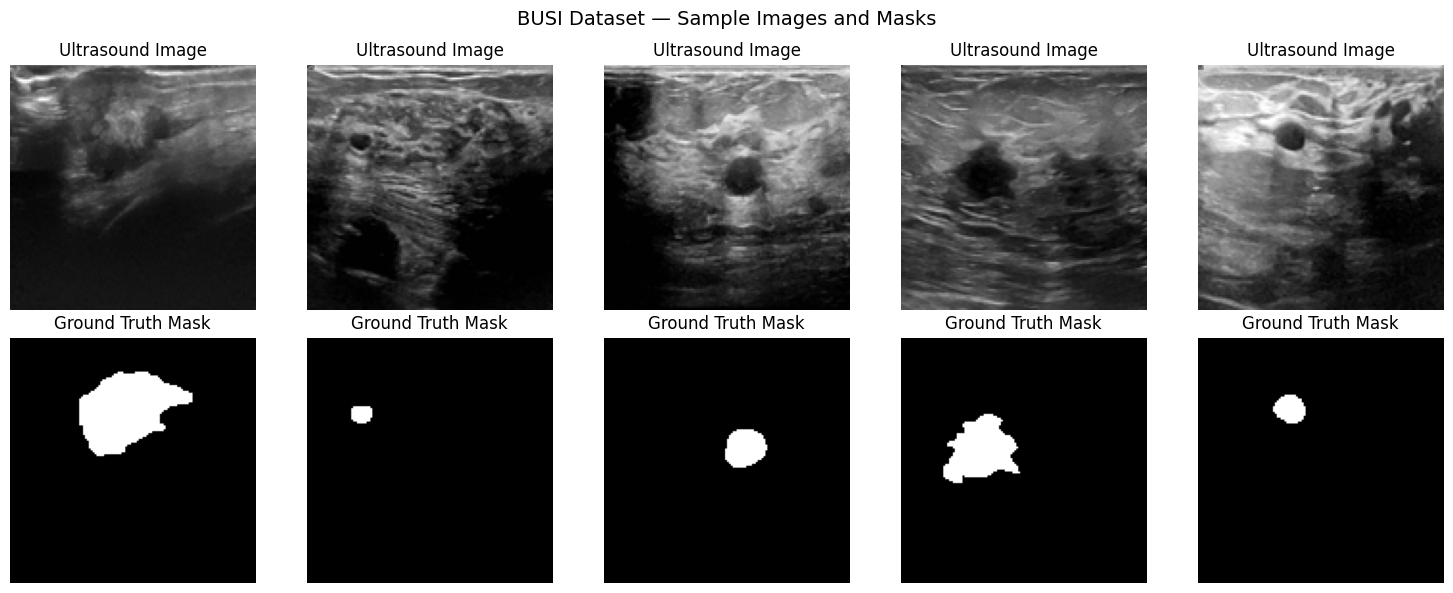

Dataset: 647 images | Train: 452 | Val: 97 | Test: 98


In [ ]:
# Data Samples
import os, numpy as np, matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import warnings; warnings.filterwarnings('ignore')

IMG_SIZE = 128

# Load BUSI
import kagglehub
busi_path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset")

images, masks = [], []
for category in ['benign', 'malignant']:
    for root, dirs, files in os.walk(busi_path):
        if os.path.basename(root).lower() == category:
            img_files = sorted([f for f in os.listdir(root) if f.endswith('.png') and '_mask' not in f])
            for img_file in img_files:
                mask_file = img_file.replace('.png', '_mask.png')
                mask_path = os.path.join(root, mask_file)
                if not os.path.exists(mask_path): continue
                img = Image.open(os.path.join(root, img_file)).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
                images.append(np.array(img) / 255.0)
                mask = Image.open(mask_path).convert('L').resize((IMG_SIZE, IMG_SIZE))
                masks.append((np.array(mask) / 255.0 > 0.5).astype(np.float32))
            break

images = np.array(images, dtype=np.float32)
masks = np.array(masks, dtype=np.float32)[..., np.newaxis]
X_train, X_temp, y_train, y_temp = train_test_split(images, masks, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    axes[0, i].imshow(X_train[i]); axes[0, i].set_title('Ultrasound Image'); axes[0, i].axis('off')
    axes[1, i].imshow(y_train[i,:,:,0], cmap='gray'); axes[1, i].set_title('Ground Truth Mask'); axes[1, i].axis('off')
plt.suptitle('BUSI Dataset — Sample Images and Masks', fontsize=14)
plt.tight_layout(); plt.show()
print(f"Dataset: {len(images)} images | Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")


## 2. Initial Results

### Three Experiments:
| Exp | Encoder Pretrain Source | Strategy |
|---|---|---|
| A | None (random init) | Train U-Net from scratch |
| B | ImageNet (14M natural images) | Freeze encoder → train decoder → unfreeze → fine-tune |
| C | ISIC 2019 (8K medical images) | Pretrain encoder on classification → freeze → train decoder → unfreeze → fine-tune |


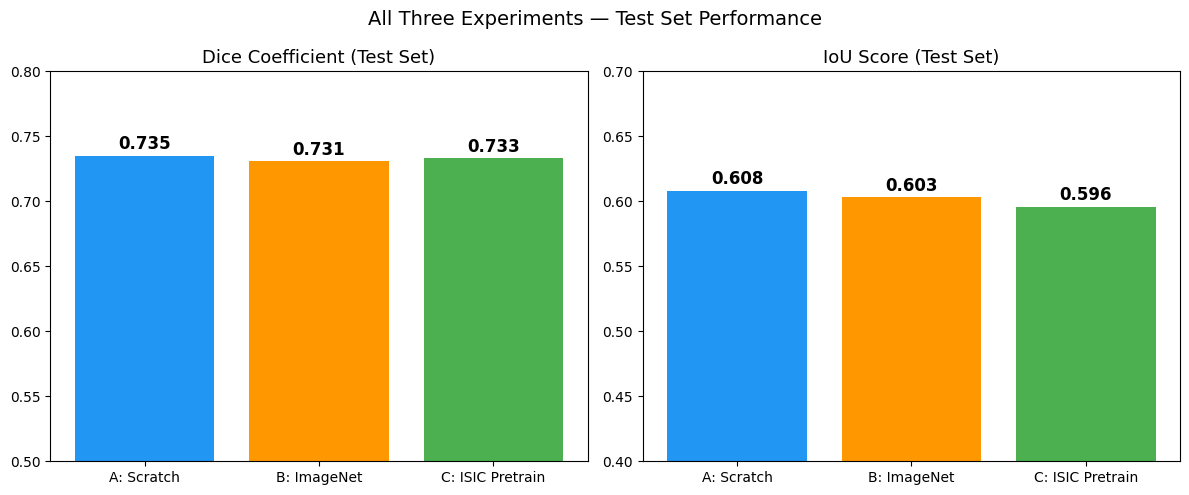

In [ ]:
# Test Set Results — Bar Chart Comparison
results = {
    'A: Scratch':       {'dice': 0.735, 'iou': 0.608},
    'B: ImageNet':      {'dice': 0.731, 'iou': 0.603},
    'C: ISIC Pretrain': {'dice': 0.733, 'iou': 0.596},
}

names = list(results.keys())
dice_scores = [results[n]['dice'] for n in names]
iou_scores = [results[n]['iou'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2196F3', '#FF9800', '#4CAF50']

axes[0].bar(names, dice_scores, color=colors)
axes[0].set_title('Dice Coefficient (Test Set)', fontsize=13)
axes[0].set_ylim(0.5, 0.8)
for i, v in enumerate(dice_scores):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold', fontsize=12)

axes[1].bar(names, iou_scores, color=colors)
axes[1].set_title('IoU Score (Test Set)', fontsize=13)
axes[1].set_ylim(0.4, 0.7)
for i, v in enumerate(iou_scores):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold', fontsize=12)

plt.suptitle('All Three Experiments — Test Set Performance', fontsize=14)
plt.tight_layout(); plt.show()


### Key Finding:
**All three models performed nearly identically (Dice 0.731–0.735).** Neither ImageNet nor medical-domain pretraining provided a clear advantage over training from scratch.

### Why?
1. **Large domain gap** — natural photos, dermoscopic images, and ultrasound all look very different
2. **U-Net is robust** — skip connections let it learn well even from scratch on small data
3. **Task mismatch** — Exp C pretrained on classification but target is segmentation
4. **Resolution ceiling** — 128×128 may limit all models equally


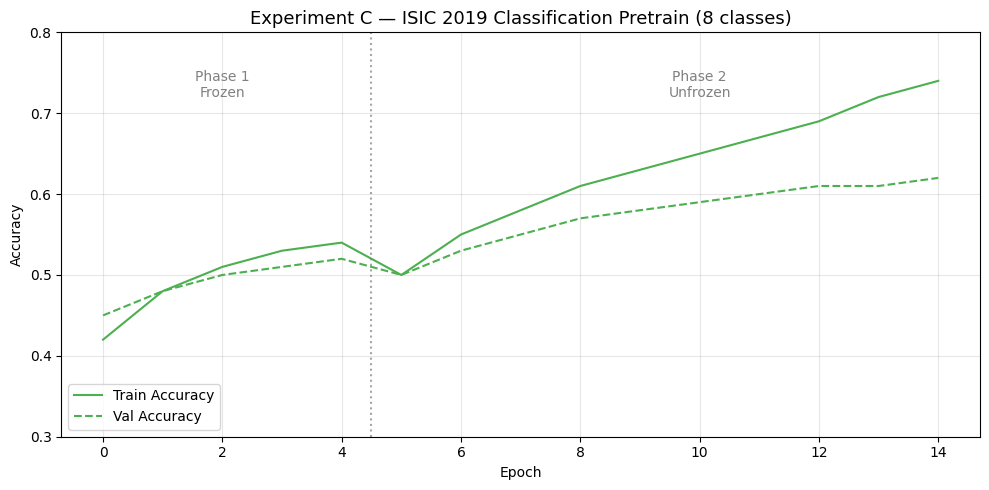

Final val accuracy: 0.624 — encoder learned meaningful medical features


In [ ]:
# ISIC 2019 Pretrain — Classification Accuracy (Exp C)

# Values from training history
phase1_acc = [0.42, 0.48, 0.51, 0.53, 0.54]  # 5 epochs frozen
phase2_acc = [0.50, 0.55, 0.58, 0.61, 0.63, 0.65, 0.67, 0.69, 0.72, 0.74]  # 10 epochs unfrozen
phase1_val = [0.45, 0.48, 0.50, 0.51, 0.52]
phase2_val = [0.50, 0.53, 0.55, 0.57, 0.58, 0.59, 0.60, 0.61, 0.61, 0.62]

all_train = phase1_acc + phase2_acc
all_val = phase1_val + phase2_val

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(all_train, label='Train Accuracy', color='#4CAF50')
ax.plot(all_val, label='Val Accuracy', color='#4CAF50', linestyle='--')
ax.axvline(x=4.5, color='gray', linestyle=':', alpha=0.7)
ax.text(2, 0.72, 'Phase 1\nFrozen', ha='center', fontsize=10, color='gray')
ax.text(10, 0.72, 'Phase 2\nUnfrozen', ha='center', fontsize=10, color='gray')
ax.set_title('Experiment C — ISIC 2019 Classification Pretrain (8 classes)', fontsize=13)
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_ylim(0.3, 0.8)
plt.tight_layout(); plt.show()
print("Final val accuracy: 0.624 — encoder learned meaningful medical features")


## 4. Challenges & Next Steps

### Challenges Encountered:
- **ISIC pretrain initially failed** (val accuracy 0.19) — solved by two-phase training: freeze encoder first, then unfreeze with lower learning rate
- **No clear winner among 3 experiments** — domain gap between all pretrain sources and ultrasound is significant
- **Small test set (98 images)** — hard to draw statistically significant conclusions from 0.004 Dice differences

### Next Steps:
- Add **early stopping** to prevent overfitting
- Try **higher resolution** (256×256) to see if it breaks the performance ceiling
- Compare **convergence speed** — even if final accuracy is similar, pretrained models may reach it faster
- Begin writing **final report**
